In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.linalg import toeplitz
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from functions import *

plt.rcParams.update({'font.size': 12})

In [21]:
borza = np.loadtxt("data/borza.dat")
ts = np.arange(len(borza))

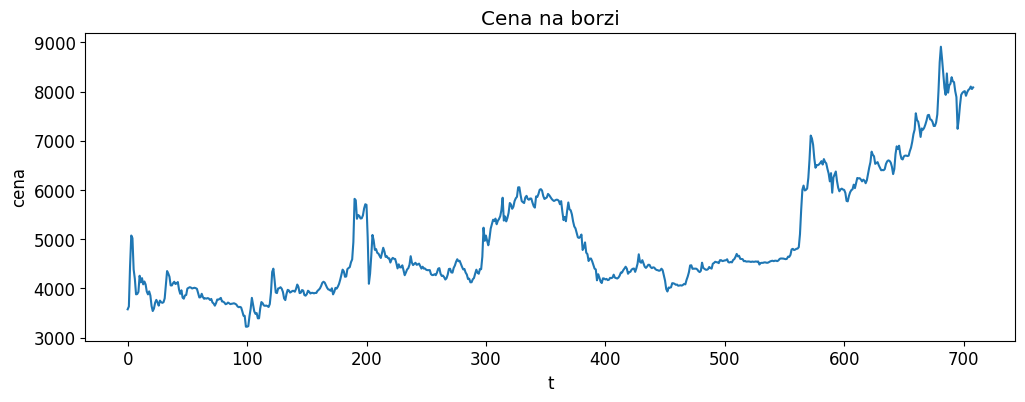

In [22]:
plt.figure(figsize=(12, 4))
plt.title('Cena na borzi')
plt.xlabel('t')
plt.ylabel('cena')
plt.plot(ts, borza)

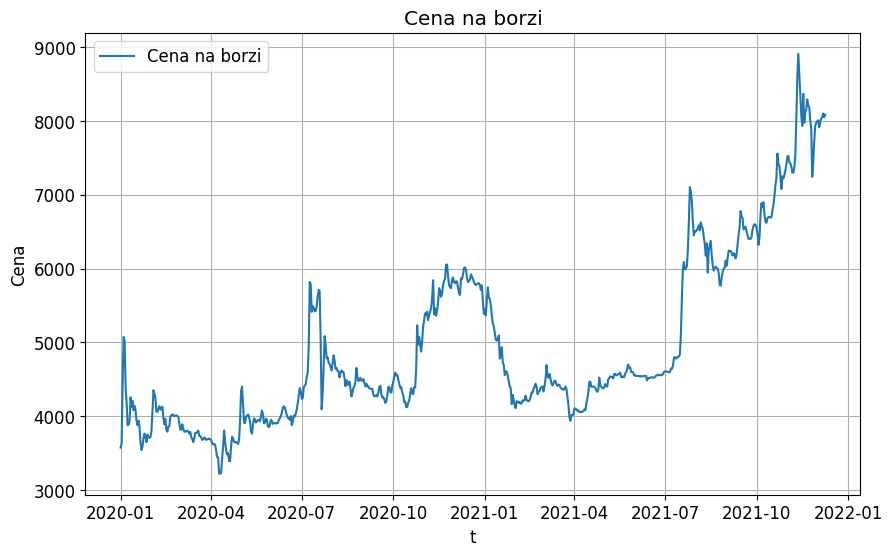

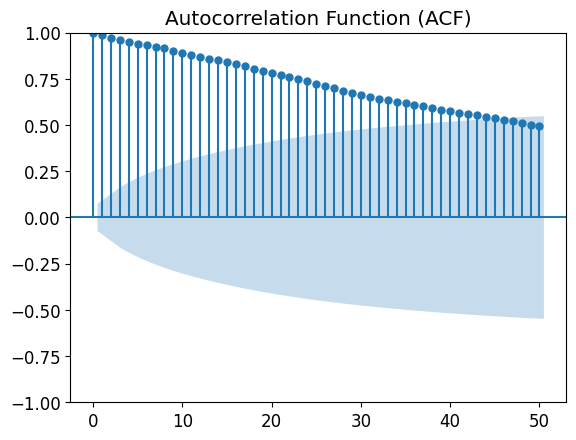

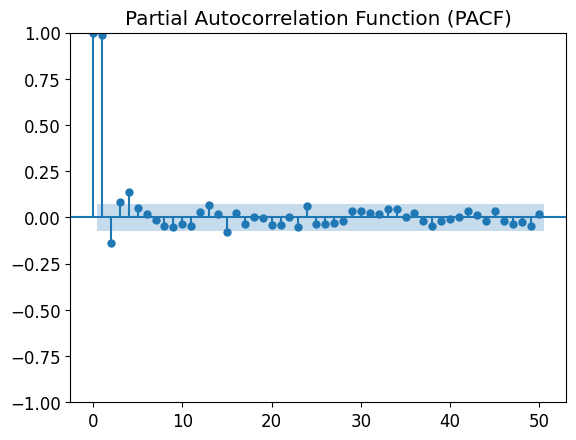

c:\Users\Tadej\AppData\Local\Programs\Python\Python39\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                  709
Model:                ARIMA(2, 2, 10)   Log Likelihood               -4406.714
Date:                Mon, 13 Jan 2025   AIC                           8839.427
Time:                        19:39:18   BIC                           8898.721
Sample:                    01-01-2020   HQIC                          8862.337
                         - 12-09-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7641      0.128    -13.821      0.000      -2.014      -1.514
ar.L2         -0.8066      0.109     -7.397      0.000      -1.020      -0.593
ma.L1          1.0270      0.641      1.601      0.1

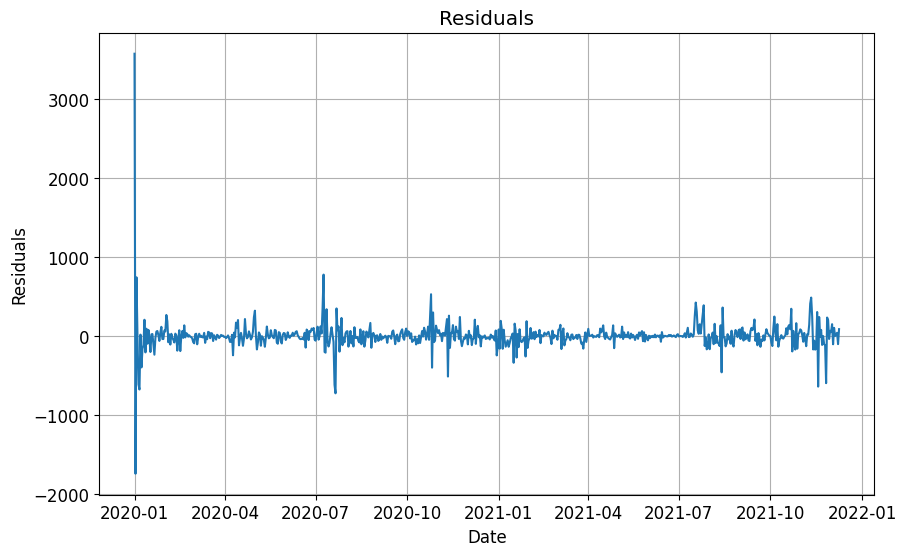

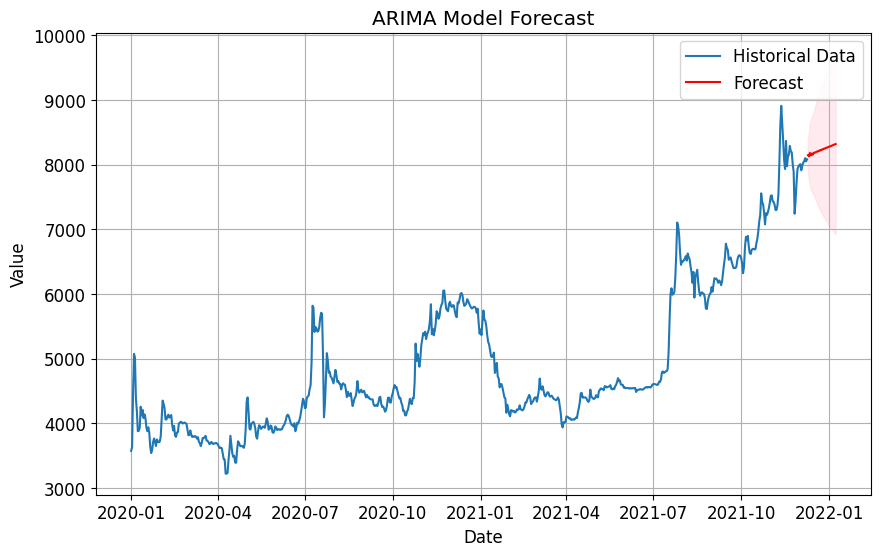

In [56]:
# Load the data
file_path = "data/borza.dat"  # Replace with your file path
data = pd.read_csv(file_path, header=None, names=["Value"])

# Create a datetime index (optional, for time-based visualization)
data.index = pd.date_range(start="2020-01-01", periods=len(data), freq="D")

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Value"], label="Cena na borzi")
plt.title("Cena na borzi")
plt.xlabel("t")
plt.ylabel("Cena")
plt.legend()
plt.grid()
plt.show()

# Step 1: Visualize the ACF (auto-correlation function) and PACF 
plot_acf(data["Value"], lags=50)
plt.title("Autocorrelation Function (ACF)")
plt.show()

plot_pacf(data["Value"], lags=50, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

# Step 2: Fit the ARIMA model
# Adjust p, d, q values here
p, d, q = 2, 2, 10  # Example parameters
model = ARIMA(data["Value"], order=(p, d, q))
fitted_model = model.fit()

# Step 3: Summarize the model
print(fitted_model.summary())

# Step 4: Plot the residuals
residuals = fitted_model.resid
plt.figure(figsize=(10, 6))
plt.plot(residuals)
plt.title("Residuals")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.grid()
plt.show()

# Step 5: Forecast future values
forecast_steps = 30  # Number of steps to forecast
forecast = fitted_model.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=forecast_steps, freq="D")
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(10, 6))
plt.plot(data.index, data["Value"], label="Historical Data")
plt.plot(forecast_index, forecast_values, label="Forecast", color="red")
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color="pink", alpha=0.3)
plt.title("ARIMA Model Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid()
plt.show()

ADF Statistic: -0.31295336419476205
p-value: 0.9236496070818142
Series is non-stationary, differencing is required.


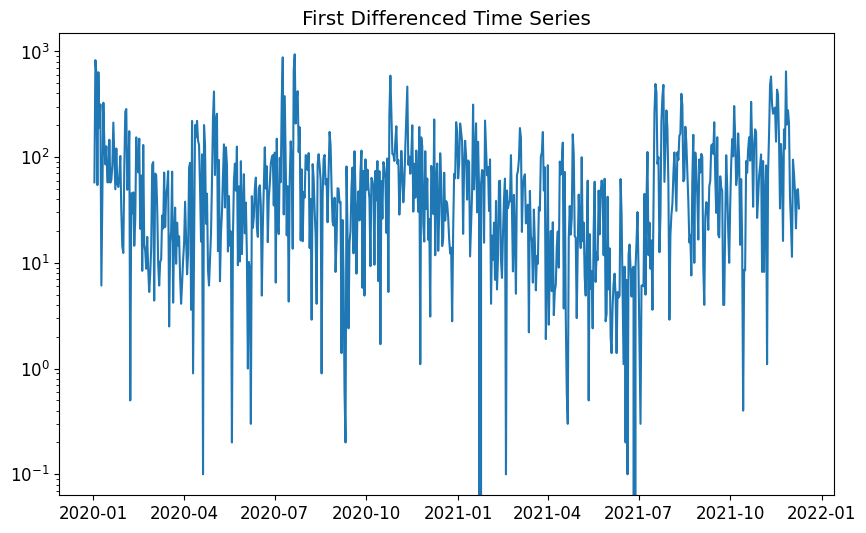

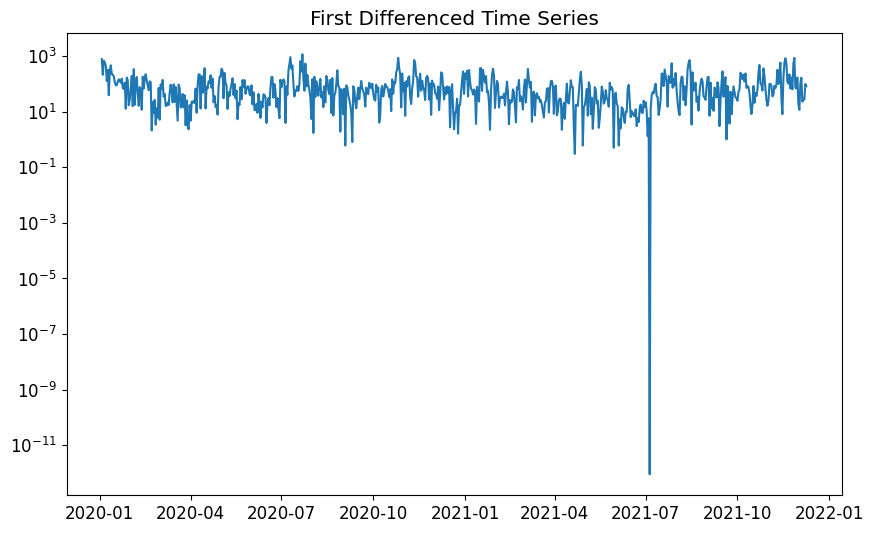

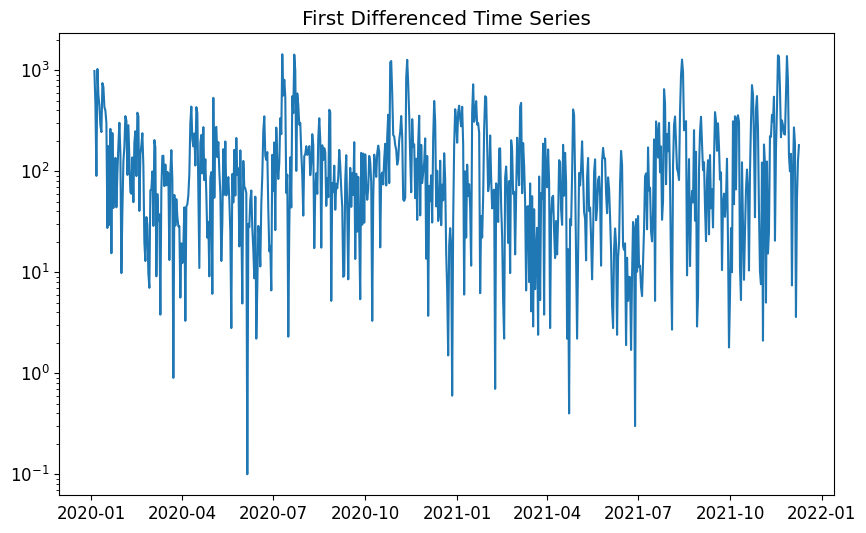

MissingDataError: exog contains inf or nans

In [53]:
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Function to apply differencing and test for stationarity
def test_stationarity(series):
    # Perform ADF test
    result = adfuller(series)
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    # If p-value is greater than 0.05, the series is non-stationary
    if result[1] > 0.05:
        print("Series is non-stationary, differencing is required.")
    else:
        print("Series is stationary.")

# Step 1: Test the original series
test_stationarity(data['Value'])

# Check for missing values and remove them
data['Value_diff_1'] = data['Value'].diff().dropna()
# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(np.abs(data['Value_diff_1']), label="First Differenced Series")
plt.title("First Differenced Time Series")
plt.yscale('log')
plt.show()

data['Value_diff_2'] = data['Value_diff_1'].diff().dropna()
# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(np.abs(data['Value_diff_2']), label="First Differenced Series")
plt.title("First Differenced Time Series")
plt.yscale('log')
plt.show()

data['Value_diff_3'] = data['Value_diff_2'].diff().dropna()
# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(np.abs(data['Value_diff_3']), label="First Differenced Series")
plt.title("First Differenced Time Series")
plt.yscale('log')
plt.show()


# Step 3: Apply second differencing if needed

# Now, perform the ADF test again
test_stationarity(data['Value_diff_1'])

test_stationarity(data['Value_diff_2'])

# Plot the differenced series
plt.figure(figsize=(10, 6))
plt.plot(data['Value_diff_1'], label="First Differenced Series")
plt.title("First Differenced Time Series")
plt.show()